In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:

class SimpleAttention(tf.keras.layers.Layer):
    def __init__(self):
         # obligatoire
         super().__init__()
         # ici : définir les attributs self.S, self.A, self.O (pour pouvoir les afficher...
         self.A=None
         self.O=None
         self.S=None

    def call(self, X,**kwargs):
     # recopier ici les calculs de l’étape précédente :
          S= X @ tf.transpose(X, perm=[0, 2, 1])
     # 2) A = ... (softmax ligne par ligne)
          A = tf.nn.softmax(S, axis=-1)

          O=A@X
          self.A=A
          self.O=O
          self.S=S
          return O

    def get_S(self):
     return self.S

    def get_A(self):
     return self.A

    def get_O(self):
     return self.O
#X = np.random.randn(10, 8)
#layer = SimpleAttention()
#O = layer(X)

#print(f"Taille de X : {X.shape}")
#print(f"Taille de O : {O.shape}")
#print(f"Ligne 3 de A : {layer.get_A()[3]}")
#print(f"Somme ligne 3 : {np.sum(layer.get_A()[3])}")

In [ ]:
class MultiHeadSimpleAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim):
        super().__init__()
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.heads = [SimpleAttention() for _ in range(num_heads)]
        self.dense = tf.keras.layers.Dense(embed_dim)

    def call(self, X, training=False,**kwargs):
        outputs = [head(X) for head in self.heads]
        concat = tf.concat(outputs, axis=-1)
        return self.dense(concat)



In [ ]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super().__init__()

        self.att = MultiHeadSimpleAttention(
            num_heads,
            embed_dim
        )

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(embed_dim)
        ])

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)

    def call(self, X, training=False,**kwargs):

        attn_output = self.att(X)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(X + attn_output)


        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

In [ ]:
vocab = {
    "the":0, "apothecary":1, "diaries":2, "pride":3, "and":4, "prejudice":5, "naruto":6,
    "jojo":7, "bizarre":8, "adventures":9, "is":10, "a":11, "anime":12, "novel":13, "your":14,
    "name":15, "one":16, "piece":17, "harry":18, "potter":19, "stranger":20, "an":21, "best":22,
    "?":23, "isn't":24, "it":25, "barrier":26, ",":27, "of":28, "not":29, "great":30, "classic":31,
    "famous":32, "really":33, "just":34, "good":35, "written":36, "by":37, "camus":38, "austen":39,
    "about":40, "character":41, "story":42, "based":43, "on":44, "manga":45, "series":46, "book":47,
    "people":48, "love":49,
}

phrases = [
    "naruto is the best anime isn't it ?",
    "one piece is a really great anime ,",
    "jojo bizarre adventures is a great anime ,",
    "your name is a famous anime isn't it ?",
    "naruto is a famous anime series isn't it ?",
    "one piece is a classic anime series ,",
    "jojo bizarre adventures is the best anime",
    "the apothecary diaries is a great anime",
    "naruto is based on a great manga series",
    "one piece is based on a famous manga",
    "your name is just a really good anime",
    "jojo bizarre adventures is based on manga ,",
    "the apothecary diaries is not a novel ,",
    "naruto is not a novel it is anime",
    "one piece is not a novel it is anime",
    "pride and prejudice is the best novel ,",
    "harry potter is the best novel isn't it ?",
    "the stranger is a classic novel by camus",
    "pride and prejudice is written by austen ,",
    "harry potter is a famous novel series ,",
    "the stranger is a really good novel ,",
    "pride and prejudice is a classic novel ,",
    "harry potter is based on a great novel",
    "the stranger is not an anime it is novel",
    "pride and prejudice is not an anime ,",
    "harry potter is not anime it is a novel",
    "the stranger is a novel about one character",
    "pride and prejudice is a story about love",
    "harry potter is a novel people really love",
    "the stranger is the best novel by camus",
]

labels = [
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
]
#label=anime

def tokeniser(phrase,vocab):
    mots=phrase.split()
    return [vocab[mot] for mot in mots]
X=[tokeniser(phrase,vocab) for phrase in phrases]
def tokeniser(phrase, vocab):
    mots = phrase.split()
    return [vocab[mot] for mot in mots]

X = [tokeniser(phrase, vocab) for phrase in phrases]
X = pad_sequences(X, maxlen=10, padding='post')
y = np.array(labels)


split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

X_train shape : (24, 10)
X_test shape  : (6, 10)


In [ ]:
vocab_size = len(vocab) + 1

embed_dim = 16
num_heads = 2
ff_dim    = 32

input = tf.keras.layers.Input(shape=(10,))
x = tf.keras.layers.Embedding(vocab_size, embed_dim)(input)
x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dropout(0.1)(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
x = tf.keras.layers.Dropout(0.1)(x)
x = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=input, outputs=x)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)



In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=4,
    validation_data=(X_test, y_test)
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5000 - loss: 0.7294 - val_accuracy: 0.0000e+00 - val_loss: 1.0586
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6250 - loss: 0.6448 - val_accuracy: 0.0000e+00 - val_loss: 0.9752
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7500 - loss: 0.5484 - val_accuracy: 0.1667 - val_loss: 0.8686
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7500 - loss: 0.5663 - val_accuracy: 0.3333 - val_loss: 0.7356
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9583 - loss: 0.4880 - val_accuracy: 0.6667 - val_loss: 0.6495
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9167 - loss: 0.4124 - val_accuracy: 0.3333 - val_loss: 0.7284
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8750 - loss: 0.3851 - val_accuracy: 0.8333 - val_loss: 0.5990
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9583 - loss: 0.3052 - val_accuracy: 0.8333 - val_loss:

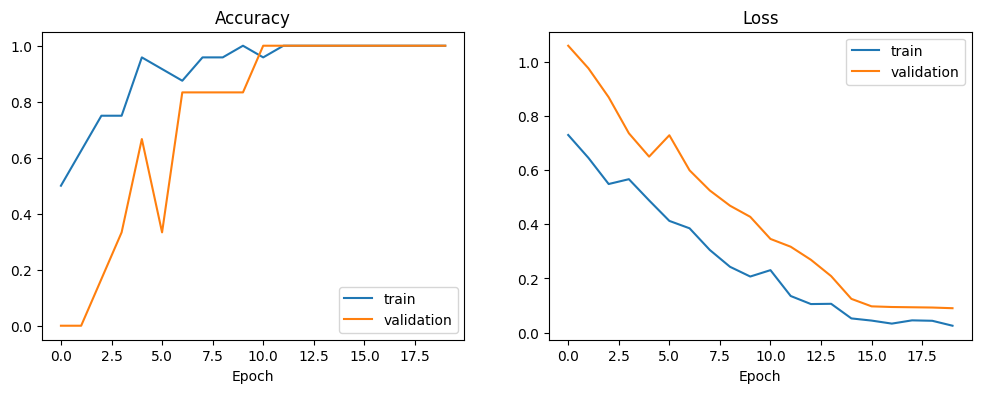

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Courbe Accuracy
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Courbe Loss
ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

In [ ]:


phrases_test = [
    "naruto is a great anime isn't it ?",
    "pride and prejudice is a classic novel ,",
]

for phrase in phrases_test:
    tokens = np.array([tokeniser(phrase, vocab)])
    tokens = pad_sequences(tokens, maxlen=10, padding='post')
    prediction = model.predict(tokens, verbose=0)
    label = "anime " if prediction[0][0] > 0.5 else "pas anime "
    print(f"{phrase}")
    print(f"Prédiction : {prediction[0][0]:.4f} → {label}\n")


naruto is a great anime isn't it ?
Prédiction : 0.9926 → anime 

pride and prejudice is a classic novel ,
Prédiction : 0.0203 → pas anime 

